In [ ]:
!pip -q install opencv-python-headless

import cv2, numpy as np, base64, time
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from IPython.display import clear_output


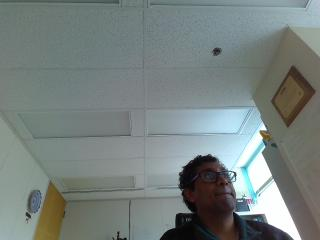

In [ ]:
def capture_frame_once(target_width=320, jpeg_quality=0.75, warmup_ms=150):
    js = f"""
    (async () => {{
      const stream = await navigator.mediaDevices.getUserMedia({{video: true, audio: false}});
      const video = document.createElement('video');
      video.srcObject = stream;
      video.setAttribute('playsinline', '');
      await video.play();
      await new Promise(r => setTimeout(r, {warmup_ms}));

      const w = video.videoWidth, h = video.videoHeight;
      const scale = {target_width} / w;
      const tw = Math.max(1, Math.round(w * scale));
      const th = Math.max(1, Math.round(h * scale));

      const canvas = document.createElement('canvas');
      canvas.width = tw; canvas.height = th;
      const ctx = canvas.getContext('2d');
      ctx.drawImage(video, 0, 0, tw, th);

      stream.getTracks().forEach(t => t.stop());
      return canvas.toDataURL('image/jpeg', {jpeg_quality});
    }})()
    """
    data_url = eval_js(js)
    img_bytes = base64.b64decode(data_url.split(',')[1])
    frame = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)  # BGR
    return frame

# quick test
cv2_imshow(capture_frame_once(320))

In [ ]:
import numpy as np

class GMMBackgroundSubtractorColorIso:
    def __init__(self, height, width, K=5,
                 alpha=0.01, D=2.5, T_bg=0.7,
                 var_init=2500.0, var_min=25.0,
                 w_init=0.02):
        """
        var_* are PER-CHANNEL variances (cov = var * I3).
        Typical scales for uint8 BGR:
          var_init ~ (50^2)=2500, var_min ~ (5^2)=25
        """
        self.H, self.W, self.K = height, width, K
        self.alpha = float(alpha)
        self.D2 = float(D * D)
        self.T_bg = float(T_bg)
        self.var_init = float(var_init)
        self.var_min = float(var_min)
        self.w_init = float(w_init)

        self.w = np.full((height, width, K), 1.0 / K, dtype=np.float32)        # weights for classes per-pixel
        self.var = np.full((height, width, K), var_init, dtype=np.float32)     # per-channel var per-pixel
        self.mu = np.zeros((height, width, K, 3), dtype=np.float32)            # BGR means
        self.initialized = False

    def _pdf_iso3(self, x, mu, var):
        # var is per-channel variance; covariance = var * I3
        diff = x - mu
        quad = np.sum(diff * diff, axis=1) / (var + 1e-6)
        return np.exp(-0.5 * quad) / np.power(var + 1e-6, 1.5)

    def apply(self, frame_bgr_u8):
        X = frame_bgr_u8.astype(np.float32)

        if not self.initialized:
            # Initialize the first component's means to the current frame's pixel values
            self.mu[:, :, 0, :] = X

            # Initialize the remaining K-1 components with random values (0-255)
            if self.K > 1:
                random_values = np.random.uniform(0, 255, size=(self.H, self.W, self.K - 1, 3)).astype(np.float32)
                self.mu[:, :, 1:, :] = random_values

            self.var[...] = self.var_init
            self.w[...] = 1.0 / self.K
            self.initialized = True

        diff = X[:, :, None, :] - self.mu
        sqnorm = np.sum(diff * diff, axis=3)                 # ||x-mu||^2
        d2 = sqnorm / (self.var + 1e-6)                      # Mahalanobis^2 for var*I3

        k_best = np.argmin(d2, axis=2)
        d2_best = np.take_along_axis(d2, k_best[:, :, None], axis=2)[:, :, 0]
        matched = d2_best <= self.D2

        # weights
        self.w *= (1.0 - self.alpha)
        rr, cc = np.indices((self.H, self.W))
        self.w[rr[matched], cc[matched], k_best[matched]] += self.alpha
        self.w /= (np.sum(self.w, axis=2, keepdims=True) + 1e-12)

        # update matched mean/var
        rrm, ccm, kb = rr[matched], cc[matched], k_best[matched]
        x_m = X[matched]
        mu_k = self.mu[rrm, ccm, kb, :]
        var_k = self.var[rrm, ccm, kb]

        pdf = self._pdf_iso3(x_m, mu_k, var_k)
        rho = np.clip(self.alpha * pdf, 0.0, 0.2).astype(np.float32)

        mu_new = (1.0 - rho)[:, None] * mu_k + rho[:, None] * x_m
        self.mu[rrm, ccm, kb, :] = mu_new

        diff_new = x_m - mu_new
        per_chan_sq = np.mean(diff_new * diff_new, axis=1)
        var_new = (1.0 - rho) * var_k + rho * per_chan_sq
        self.var[rrm, ccm, kb] = np.maximum(var_new, self.var_min)

        # replace unmatched
        unmatched = ~matched
        if np.any(unmatched):
            ru, cu = rr[unmatched], cc[unmatched]
            x_u = X[unmatched]
            k_minw = np.argmin(self.w[ru, cu, :], axis=1)

            self.mu[ru, cu, k_minw, :] = x_u
            self.var[ru, cu, k_minw] = self.var_init
            self.w[ru, cu, k_minw] = self.w_init
            self.w[ru, cu, :] /= (np.sum(self.w[ru, cu, :], axis=1, keepdims=True) + 1e-12)

        # background decision
        score = self.w / (np.sqrt(self.var) + 1e-6)
        order = np.argsort(-score, axis=2)
        w_sorted = np.take_along_axis(self.w, order, axis=2)
        cumw = np.cumsum(w_sorted, axis=2)
        B = np.argmax(cumw >= self.T_bg, axis=2) + 1

        rank_pos = np.argmax(order == k_best[:, :, None], axis=2)
        is_bg = matched & (rank_pos < B)

        return np.where(is_bg, 0, 255).astype(np.uint8)

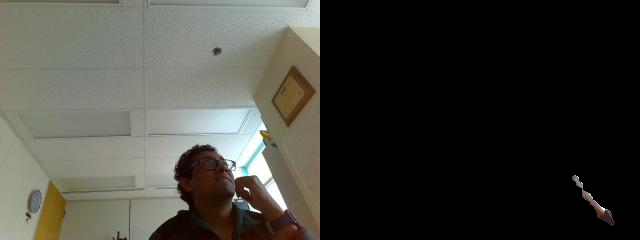

KeyboardInterrupt: 

In [ ]:
TARGET_WIDTH = 320   # smaller => faster in Colab
K = 5
alpha = 0.05
D = 3
T_bg = 0.8

frame = capture_frame_once(TARGET_WIDTH)
h, w = frame.shape[:2]

sub = GMMBackgroundSubtractorColorIso(h, w, K=K, alpha=alpha, D=D, T_bg=T_bg,
                                      var_init=225.0, var_min=36.0)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

print("Running… stop with Runtime → Interrupt execution.")
t0 = time.time()
n = 0
while True:
    frame = capture_frame_once(TARGET_WIDTH)
    fg = sub.apply(frame)

    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel, iterations=1)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2)

    fg_img = cv2.bitwise_and(frame, frame, mask=fg)

    # dim = (frame * 0.25).astype(np.uint8)
    # overlay = dim.copy()
    # overlay[fg == 255] = frame[fg == 255]

    # vis = np.hstack([frame, fg_img, overlay])
    vis = np.hstack([frame, fg_img])
    clear_output(wait=True)
    cv2_imshow(vis)